## Testing the vLLM Server


### Prerequisites

Before running this notebook, ensure that the vLLM server is running with the plugin enabled.

#### Test the default IOProcessor

Start the server with the default IOProcessor

```bash
vllm serve mgazz/prithvi-eo-burnscars \
   --skip-tokenizer-init \
   --enable-mm-embeds \
   --max-num-seqs 32 \
   --io-processor-plugin terratorch_segmentation \
   --enforce-eager
```

Try the inference service.

In [2]:
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import requests
import base64
import json
import requests
import io
from PIL import Image
import matplotlib.pyplot as plt

### Load and Display Original Image

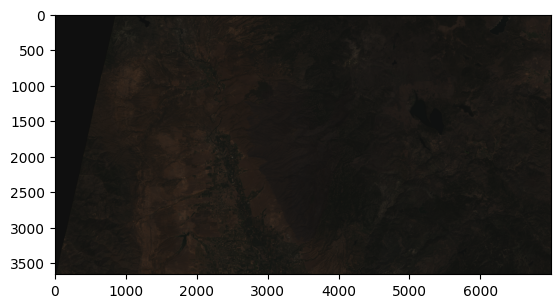

In [7]:
# Read the original image and get its bounds
input_path = "../samples/park_fire_scaled.tif"

with rasterio.open(input_path) as img_src:
    # Read RGB bands
    img_data = img_src.read([3, 2, 1])
    # Transpose to (height, width, channels) for matplotlib
    img_rgb = np.transpose(img_data, (1, 2, 0))
    # Normalize to 0-1 range for display
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())
    
plt.imshow(img_rgb)
plt.show()

### Send Inference Request to vLLM

In [8]:
# Process remote image via URL
#payload = {
#    "data": {
#        "data": "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/examples/India_900498_S2Hand.tif",
#        "indices": [0, 1, 2, 3, 4, 5],
#        "data_format": "url",
#        "out_data_format": "b64_json",
#        "image_format": "tiff",
#    },
#    "model": "1_run_model_in_vllm",
#}

# Process path to local storage file
payload = {
    "data": {
        "data": "/home/sagemaker-user/ESA-NASA-Workshop-2026/Day 2/Track 3/Operational-GeoAI-Model-Serving/Part2/samples/park_fire_scaled.tif",
        "indices": [0, 1, 2, 3, 4, 5],
        "data_format": "path",
        "out_data_format": "b64_json",
        "image_format": "tiff",
    },
    "model": "mgazz/prithvi-eo-burnscars",
}

response = requests.post(
    "http://localhost:8000/pooling",
    headers={"Content-Type": "application/json"},
    data=json.dumps(payload),
)

if response.status_code == 200:
    result = response.json()
    mask_b64 = result["data"]["data"]
    mask_bytes = base64.b64decode(mask_b64)
    with open("mask.tiff", "wb") as f:
        f.write(mask_bytes)
    print("Segmentation mask saved as mask.tiff")
else:
    print(f"Error: Received status code {response.status_code}")
    print(f"Response: {response.text}")

Segmentation mask saved as mask.tiff


### Read the Mask

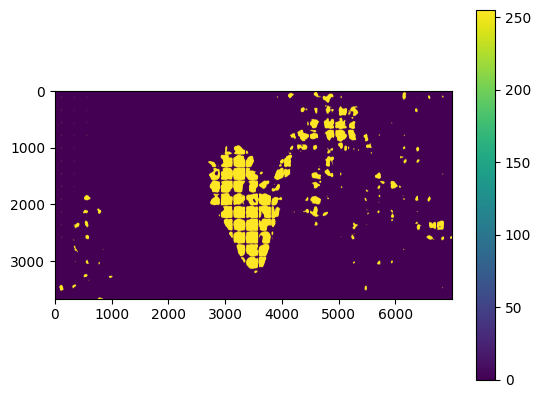

In [9]:
# Read the mask
with rasterio.open('mask.tiff') as mask_src:
    mask = mask_src.read(1)

plt.imshow(mask)
plt.colorbar()  # optional
plt.show()

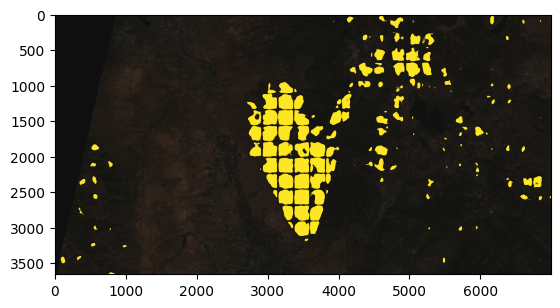

In [10]:
masked = np.ma.masked_where(mask == 0, mask)
plt.imshow(img_rgb)
plt.imshow(masked)

#### Test custom IOProcessor

Stop the current vLLM server (Ctrl-C) and start the server with the new IOProcessor

```bash
vllm serve mgazz/prithvi-eo-burnscars \
   --skip-tokenizer-init \
   --enable-mm-embeds \
   --max-num-seqs 32 \
   --io-processor-plugin mask_closing \
   --enforce-eager
```

Try the inference again.

In [4]:
# Process remote image via URL
#payload = {
#    "data": {
#        "data": "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/examples/India_900498_S2Hand.tif",
#        "indices": [1, 2, 3, 8, 11, 12],
#        "data_format": "url",
#        "out_data_format": "b64_json",
#        "image_format": "tiff",
#    },
#    "model": "1_run_model_in_vllm",
#}

# Process path to local storage file
payload = {
    "data": {
        "data": "/home/sagemaker-user/ESA-NASA-Workshop-2026/Day 2/Track 3/Operational-GeoAI-Model-Serving/Part2/samples/park_fire_scaled.tif",
        "indices": [0,1,2,3,4,5],
        "data_format": "path",
        "out_data_format": "b64_json",
        "image_format": "tiff",
        "morph_close_enabled": True
    },
    "model": "mgazz/prithvi-eo-burnscars",
}

response = requests.post(
    "http://localhost:8000/pooling",
    headers={"Content-Type": "application/json"},
    data=json.dumps(payload),
)

if response.status_code == 200:
    result = response.json()
    mask_b64 = result["data"]["data"]
    mask_bytes = base64.b64decode(mask_b64)
    with open("mask.tiff", "wb") as f:
        f.write(mask_bytes)
    print("Segmentation mask saved as mask.tiff")
else:
    print(f"Error: Received status code {response.status_code}")
    print(f"Response: {response.text}")

Segmentation mask saved as mask.tiff


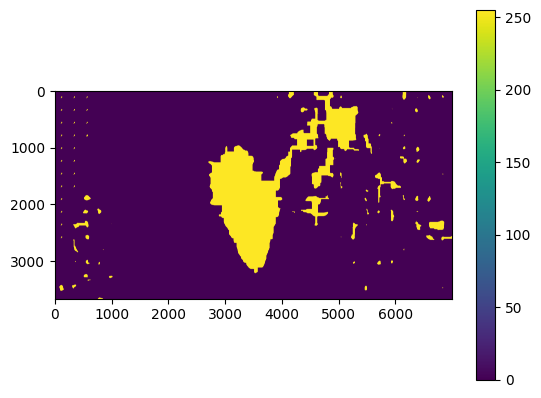

In [5]:
with rasterio.open('mask.tiff') as mask_src:
    mask = mask_src.read(1)
plt.imshow(mask)
plt.colorbar()